# Diabetes Risk Analysis
### End-to-end data science project — EDA, Prediction & Patient Segmentation

**Dataset:** 10,000 patients with clinical and lifestyle features  
**Tools:** Python, Pandas, Seaborn, Scikit-learn  
**Goal:** Explore diabetes risk factors, build a prediction model, and segment patients into meaningful health profiles

## 1. Setup & Data Loading

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('diabetes_dataset.csv', index_col=0)
print("Shape:", df.shape)
print("\nFirst 3 rows:")
df.head(3)

Shape: (10000, 20)

First 3 rows:


,Age,Sex,Ethnicity,BMI,Waist_Circumference,Fasting_Blood_Glucose,HbA1c,Blood_Pressure_Systolic,Blood_Pressure_Diastolic,Cholesterol_Total,Cholesterol_HDL,Cholesterol_LDL,GGT,Serum_Urate,Physical_Activity_Level,Dietary_Intake_Calories,Alcohol_Consumption,Smoking_Status,Family_History_of_Diabetes,Previous_Gestational_Diabetes
0,58,Female,White,35.8,83.4,123.9,10.9,152,114,197.8,50.2,99.2,37.5,7.2,Moderate,1538,Moderate,Never,0,1
1,48,Male,Asian,24.1,71.4,183.7,12.8,103,91,261.6,62.0,146.4,88.5,6.1,Moderate,2653,Moderate,Current,0,1
2,34,Female,Black,25.0,113.8,142.0,14.5,179,104,261.0,32.1,164.1,56.2,6.9,Low,1684,Heavy,Former,1,0


## 2. Data Quality Check
Checking for null values, data types, and basic statistics.

In [2]:
print("Null values:")
print(df.isnull().sum())
print("\nData types:")
print(df.dtypes)
print("\nBasic stats:")
df.describe().round(2)

Null values:
Age                                 0
Sex                                 0
Ethnicity                           0
BMI                                 0
Waist_Circumference                 0
Fasting_Blood_Glucose               0
HbA1c                               0
Blood_Pressure_Systolic             0
Blood_Pressure_Diastolic            0
Cholesterol_Total                   0
Cholesterol_HDL                     0
Cholesterol_LDL                     0
GGT                                 0
Serum_Urate                         0
Physical_Activity_Level             0
Dietary_Intake_Calories             0
Alcohol_Consumption              3320
Smoking_Status                      0
Family_History_of_Diabetes          0
Previous_Gestational_Diabetes       0
dtype: int64

Data types:
Age                                int64
Sex                               object
Ethnicity                         object
BMI                              float64
Waist_Circumference              floa

,Age,BMI,Waist_Circumference,Fasting_Blood_Glucose,HbA1c,Blood_Pressure_Systolic,Blood_Pressure_Diastolic,Cholesterol_Total,Cholesterol_HDL,Cholesterol_LDL,GGT,Serum_Urate,Dietary_Intake_Calories,Family_History_of_Diabetes,Previous_Gestational_Diabetes
count,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00
mean,44.62,29.42,94.80,134.78,9.51,134.16,89.56,225.17,55.02,134.35,55.17,5.50,2742.48,0.51,0.52
std,14.34,6.17,14.38,37.63,3.18,26.11,17.24,42.96,14.54,37.50,25.88,1.46,716.64,0.50,0.50
min,20.00,18.50,70.00,70.00,4.00,90.00,60.00,150.00,30.00,70.00,10.00,3.00,1500.00,0.00,0.00
25%,32.00,24.10,82.20,102.18,6.80,112.00,75.00,187.88,42.30,101.68,32.60,4.20,2129.00,0.00,0.00
50%,45.00,29.50,94.90,134.50,9.50,134.00,89.00,225.50,55.20,134.40,55.45,5.50,2727.00,1.00,1.00
75%,57.00,34.70,107.00,167.80,12.30,157.00,105.00,262.40,67.90,166.40,77.50,6.80,3368.00,1.00,1.00
max,69.00,40.00,120.00,200.00,15.00,179.00,119.00,300.00,80.00,200.00,100.00,8.00,3999.00,1.00,1.00


## 3. Data Cleaning
Filling missing  values and creating the target variable using WHO medical standards.

In [3]:
print("Missing before:", df['Alcohol_Consumption'].isnull().sum())

df['Alcohol_Consumption'] = df['Alcohol_Consumption'].fillna('None')

print("Missing after:", df['Alcohol_Consumption'].isnull().sum())
print("\nAlcohol_Consumption values:")
print(df['Alcohol_Consumption'].value_counts())

Missing before: 3320
Missing after: 0

Alcohol_Consumption values:
Alcohol_Consumption
Moderate    3373
None        3320
Heavy       3307
Name: count, dtype: int64


In [4]:
# Define high risk: HbA1c >= 6.5 OR Fasting Blood Glucose >= 126 (WHO standard)
df['Diabetic'] = ((df['HbA1c'] >= 6.5) | (df['Fasting_Blood_Glucose'] >= 126)).astype(int)

print("Diabetic distribution:")
print(df['Diabetic'].value_counts())
print(f"\nDiabetes rate: {df['Diabetic'].mean()*100:.1f}%")

Diabetic distribution:
Diabetic
1    9047
0     953
Name: count, dtype: int64

Diabetes rate: 90.5%


## 4. Exploratory Data Analysis (EDA)
### 4.1 Age & BMI distributions by diabetic status

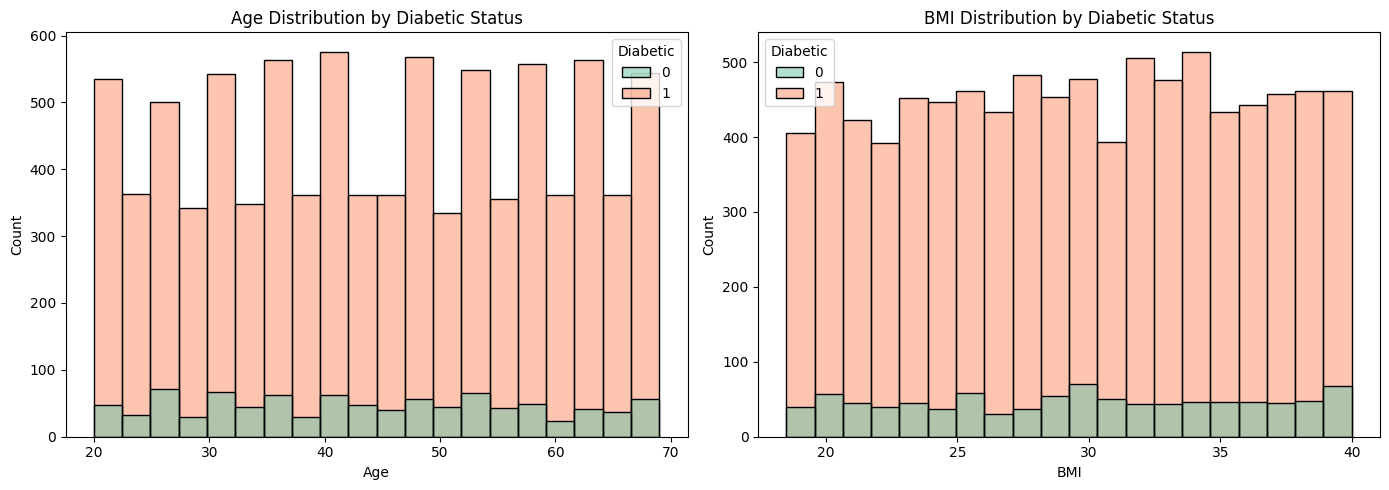

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(data=df, x='Age', hue='Diabetic', ax=axes[0], palette='Set2', bins=20)
axes[0].set_title('Age Distribution by Diabetic Status')

sns.histplot(data=df, x='BMI', hue='Diabetic', ax=axes[1], palette='Set2', bins=20)
axes[1].set_title('BMI Distribution by Diabetic Status')

plt.tight_layout()
plt.show()

### 4.2 Key clinical markers by diabetic status
> HbA1c and Fasting Blood Glucose show the clearest separation between diabetic and non-diabetic patients.

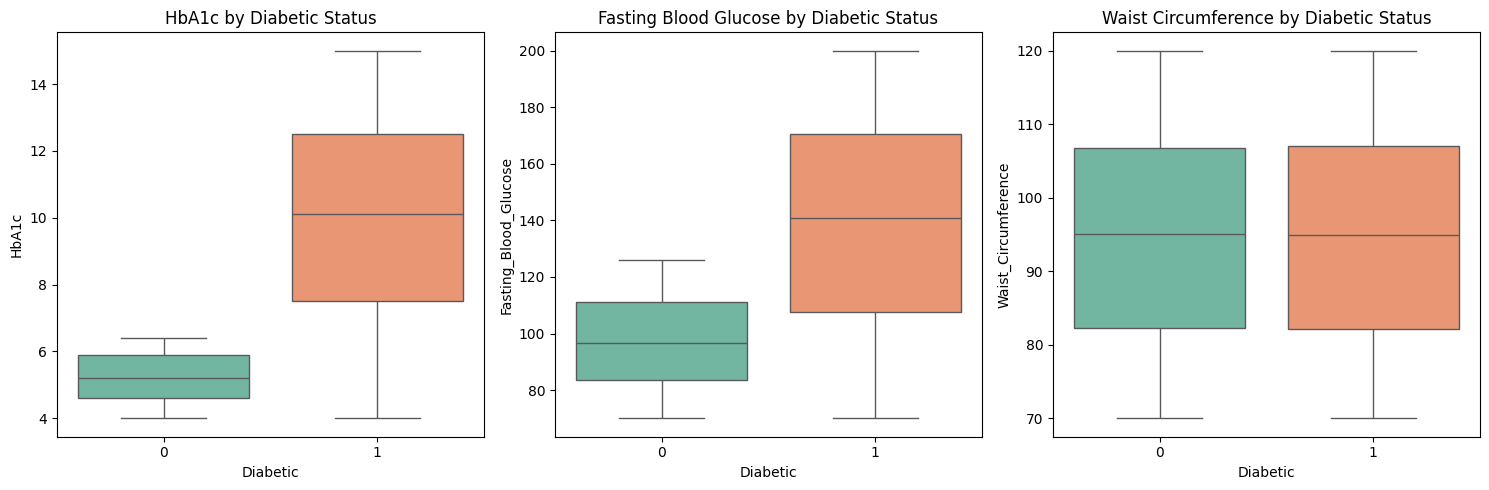

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

sns.boxplot(data=df, x='Diabetic', y='HbA1c', ax=axes[0], palette='Set2')
axes[0].set_title('HbA1c by Diabetic Status')

sns.boxplot(data=df, x='Diabetic', y='Fasting_Blood_Glucose', ax=axes[1], palette='Set2')
axes[1].set_title('Fasting Blood Glucose by Diabetic Status')

sns.boxplot(data=df, x='Diabetic', y='Waist_Circumference', ax=axes[2], palette='Set2')
axes[2].set_title('Waist Circumference by Diabetic Status')

plt.tight_layout()
plt.show()

### 4.3 Lifestyle factors vs diabetes rate
> Smoking, alcohol, and physical activity show similar diabetes rates across groups — clinical markers matter more than lifestyle alone.

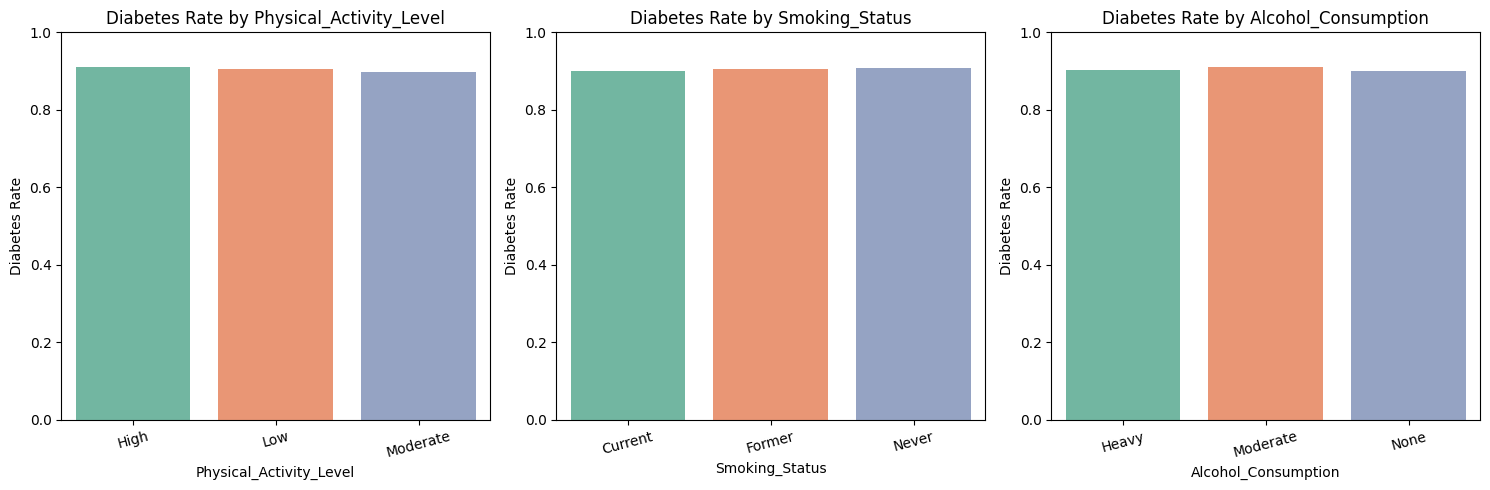

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, col in zip(axes, ['Physical_Activity_Level', 'Smoking_Status', 'Alcohol_Consumption']):
    rate = df.groupby(col)['Diabetic'].mean().reset_index()
    sns.barplot(data=rate, x=col, y='Diabetic', ax=ax, palette='Set2')
    ax.set_title(f'Diabetes Rate by {col}')
    ax.set_ylabel('Diabetes Rate')
    ax.set_ylim(0, 1)
    ax.tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()

### 4.4 Correlation heatmap — all clinical markers
> HbA1c (0.44) and Fasting Blood Glucose (0.32) are the strongest numeric predictors of diabetes.

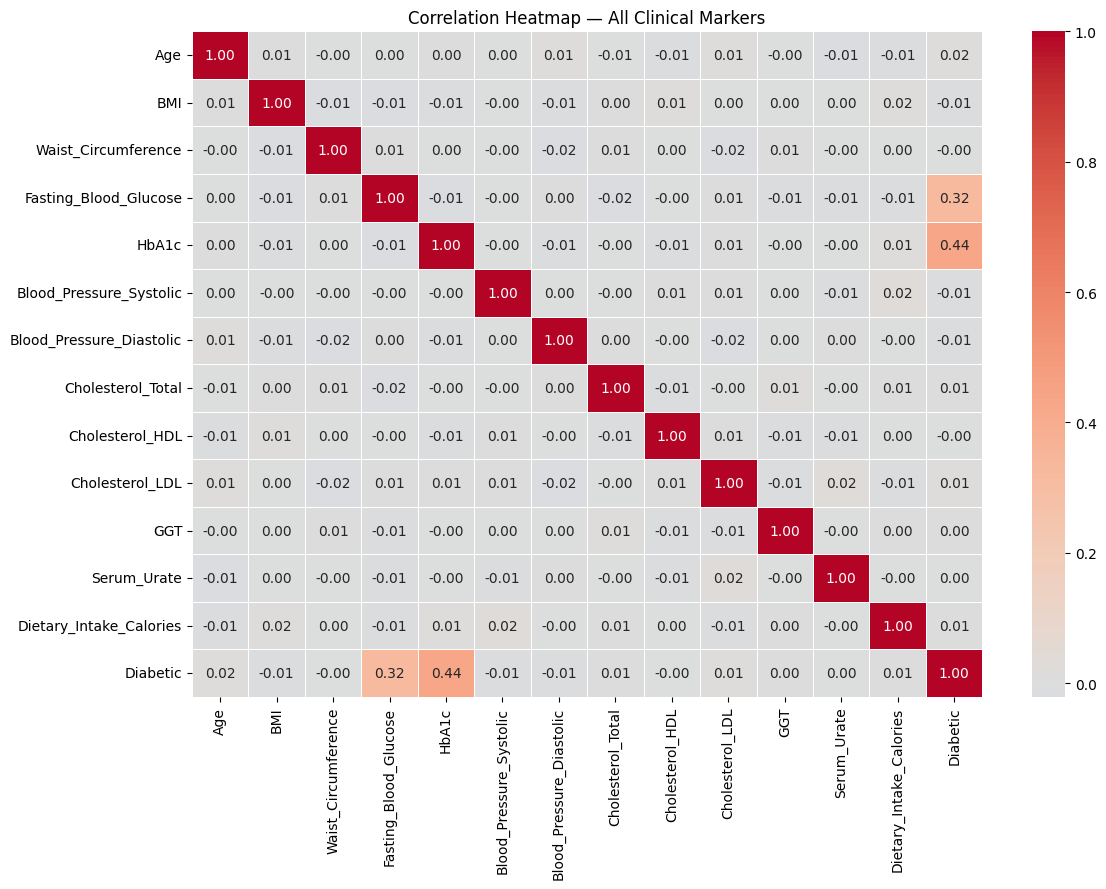

In [8]:
numeric_cols = ['Age', 'BMI', 'Waist_Circumference', 'Fasting_Blood_Glucose',
                'HbA1c', 'Blood_Pressure_Systolic', 'Blood_Pressure_Diastolic',
                'Cholesterol_Total', 'Cholesterol_HDL', 'Cholesterol_LDL',
                'GGT', 'Serum_Urate', 'Dietary_Intake_Calories', 'Diabetic']

plt.figure(figsize=(12, 9))
sns.heatmap(df[numeric_cols].corr(), annot=True, fmt='.2f',
            cmap='coolwarm', center=0, linewidths=0.5)
plt.title('Correlation Heatmap — All Clinical Markers')
plt.tight_layout()
plt.show()

## 5. Diabetes Risk Prediction Model
### 5.1 First attempt — Random Forest (with data leakage)
> **Note:** This model achieves 100% accuracy because HbA1c and Fasting Blood Glucose were used to *define* the target — a classic data leakage problem.

In [9]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder

df_model = df.copy()
cat_cols = ['Sex', 'Ethnicity', 'Physical_Activity_Level',
            'Alcohol_Consumption', 'Smoking_Status']
for col in cat_cols:
    df_model[col] = LabelEncoder().fit_transform(df_model[col])

X = df_model.drop(columns=['Diabetic'])
y = df_model['Diabetic']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       181
           1       1.00      1.00      1.00      1819

    accuracy                           1.00      2000
   macro avg       1.00      1.00      1.00      2000
weighted avg       1.00      1.00      1.00      2000



### 5.2 Fixed model — removing leaky features
> After removing HbA1c and Fasting Blood Glucose, the model reveals that lifestyle/demographic features alone cannot reliably predict diabetes — consistent with medical knowledge that blood tests are required for diagnosis.

In [10]:
# Drop the columns used to define Diabetic (data leakage)
X = df_model.drop(columns=['Diabetic', 'HbA1c', 'Fasting_Blood_Glucose'])
y = df_model['Diabetic']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model2 = RandomForestClassifier(n_estimators=100, random_state=42)
model2.fit(X_train, y_train)
y_pred2 = model2.predict(X_test)

print("Model without leaky features:")
print(classification_report(y_test, y_pred2))

Model without leaky features:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00       181
           1       0.91      1.00      0.95      1819

    accuracy                           0.91      2000
   macro avg       0.45      0.50      0.48      2000
weighted avg       0.83      0.91      0.87      2000



### 5.3 Balanced model — handling class imbalance
> With 90.5% diabetic patients, the dataset is heavily imbalanced. We downsample the majority class to give both classes equal representation.

In [11]:
from sklearn.utils import resample

# Separate classes
df_majority = df_model[df_model['Diabetic'] == 1]
df_minority = df_model[df_model['Diabetic'] == 0]

# Downsample majority to match minority
df_majority_down = resample(df_majority, replace=False,
                             n_samples=len(df_minority), random_state=42)
df_balanced = pd.concat([df_majority_down, df_minority])

print("Balanced dataset:")
print(df_balanced['Diabetic'].value_counts())

X = df_balanced.drop(columns=['Diabetic', 'HbA1c', 'Fasting_Blood_Glucose'])
y = df_balanced['Diabetic']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model3 = RandomForestClassifier(n_estimators=100, random_state=42)
model3.fit(X_train, y_train)
y_pred3 = model3.predict(X_test)

print("\nBalanced model results:")
print(classification_report(y_test, y_pred3))

Balanced dataset:
Diabetic
1    953
0    953
Name: count, dtype: int64

Balanced model results:
              precision    recall  f1-score   support

           0       0.48      0.50      0.49       194
           1       0.46      0.43      0.44       188

    accuracy                           0.47       382
   macro avg       0.47      0.47      0.47       382
weighted avg       0.47      0.47      0.47       382



## 6. Patient Segmentation — K-Means Clustering
### 6.1 Finding optimal number of clusters (Elbow Method)

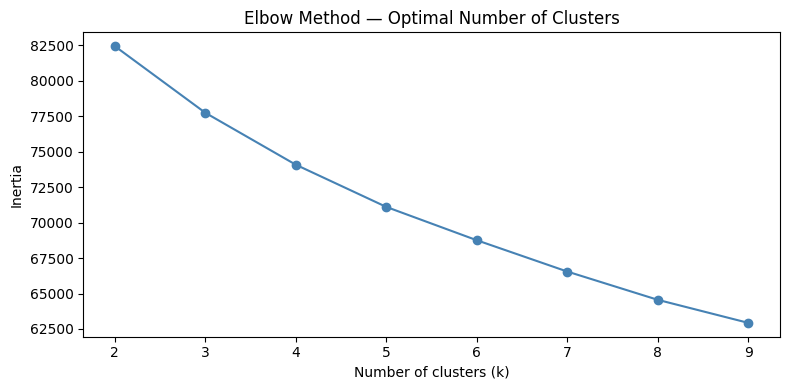

In [12]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# Use key clinical features for clustering
cluster_features = ['Age', 'BMI', 'Waist_Circumference',
                    'Blood_Pressure_Systolic', 'Cholesterol_Total',
                    'Cholesterol_HDL', 'GGT', 'Serum_Urate',
                    'Dietary_Intake_Calories']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df[cluster_features])

# Find optimal clusters using inertia (elbow method)
inertias = []
for k in range(2, 10):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(range(2, 10), inertias, marker='o', color='steelblue')
plt.title('Elbow Method — Optimal Number of Clusters')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia')
plt.tight_layout()
plt.show()


### 6.2 Cluster profiles — 4 patient groups identified

Cluster profiles:
          Age   BMI  Waist_Circumference  Blood_Pressure_Systolic  \
Cluster                                                             
0        55.7  30.1                 93.8                    132.7   
1        34.3  28.4                 95.2                    137.3   
2        52.8  30.5                 95.4                    133.8   
3        35.6  28.6                 94.8                    132.9   

         Cholesterol_Total  Cholesterol_HDL   GGT  Diabetic  
Cluster                                                      
0                    194.6             45.1  51.5       0.9  
1                    191.1             64.4  55.2       0.9  
2                    256.7             66.7  55.2       0.9  
3                    257.1             43.7  58.7       0.9  


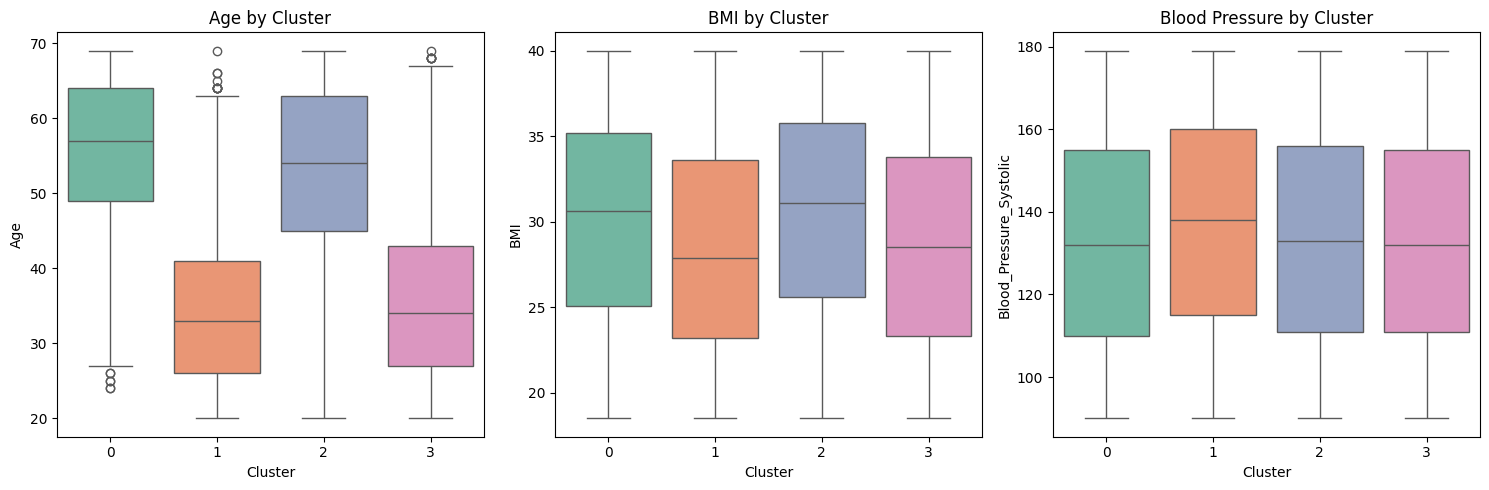

In [13]:
km_final = KMeans(n_clusters=4, random_state=42, n_init=10)
df['Cluster'] = km_final.fit_predict(X_scaled)

# Profile each cluster
profile = df.groupby('Cluster')[['Age', 'BMI', 'Waist_Circumference',
                                  'Blood_Pressure_Systolic', 'Cholesterol_Total',
                                  'Cholesterol_HDL', 'GGT', 'Diabetic']].mean().round(1)
print("Cluster profiles:")
print(profile)

# Visualize
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

sns.boxplot(data=df, x='Cluster', y='Age', ax=axes[0], palette='Set2')
axes[0].set_title('Age by Cluster')

sns.boxplot(data=df, x='Cluster', y='BMI', ax=axes[1], palette='Set2')
axes[1].set_title('BMI by Cluster')

sns.boxplot(data=df, x='Cluster', y='Blood_Pressure_Systolic', ax=axes[2], palette='Set2')
axes[2].set_title('Blood Pressure by Cluster')

plt.tight_layout()
plt.show()

## 7. Feature Importance
Which features contribute most to diabetes prediction (excluding clinical blood markers)?

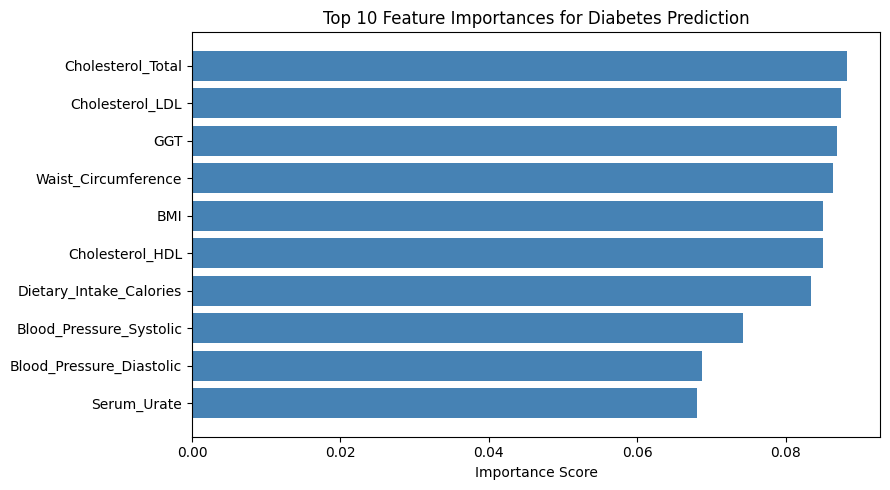

In [14]:
# Retrain on full data with all features except leaky ones
X_full = df_model.drop(columns=['Diabetic', 'HbA1c', 'Fasting_Blood_Glucose'])
y_full = df_model['Diabetic']

final_model = RandomForestClassifier(n_estimators=100, random_state=42)
final_model.fit(X_full, y_full)

importance = pd.DataFrame({
    'Feature': X_full.columns,
    'Importance': final_model.feature_importances_
}).sort_values('Importance', ascending=True).tail(10)

plt.figure(figsize=(9, 5))
plt.barh(importance['Feature'], importance['Importance'], color='steelblue')
plt.title('Top 10 Feature Importances for Diabetes Prediction')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

## 8. Key Findings & Conclusions

**EDA findings:**
- HbA1c ≥ 6.5 and Fasting Blood Glucose ≥ 126 are the definitive diabetes markers (WHO standards)
- Lifestyle factors (smoking, alcohol, activity) show no strong differentiation on their own
- BMI and age are evenly distributed across diabetic/non-diabetic groups

**Modelling findings:**
- Data leakage is a critical pitfall — always check if features define the target
- Without blood test results, lifestyle features alone yield only ~47% accuracy
- This is medically accurate: you cannot diagnose diabetes without clinical blood tests

**Clustering findings:**
- 4 distinct patient profiles emerge based on age, BMI, cholesterol, and blood pressure
- Cluster 0: Older patients, lower HDL, hypertension risk
- Cluster 1: Young patients, healthiest cholesterol profile
- Cluster 2: Middle-aged, high total cholesterol but good HDL
- Cluster 3: Young patients, high cholesterol and low HDL — highest cardiovascular risk

**Recommendation:** Routine blood tests (HbA1c, fasting glucose) remain essential for diabetes screening. Lifestyle interventions should target Clusters 0 and 3 as highest risk groups.